# Salary Prediction - Linear Regression Baseline
This notebook loads the salary dataset, trains a linear regression baseline, and evaluates its performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Salary_Data.csv')
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [8]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


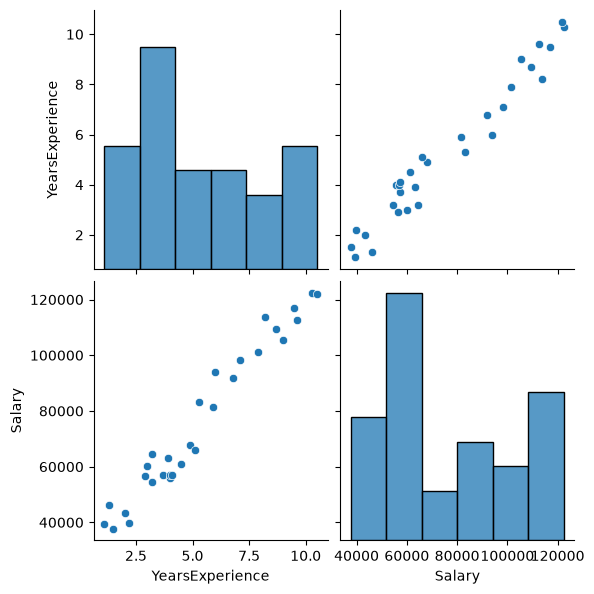

In [5]:
import seaborn as sns

sns.pairplot(df, height=3)
plt.show()


In [3]:
X = df[['YearsExperience']]
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Intercept:', model.intercept_)
print('Coefficient:', model.coef_[0])
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

Intercept: 25321.583011776813
Coefficient: 9423.815323030976
MAE: 6286.453830757749
RMSE: 7059.04362190151
R2: 0.9024461774180497


/Users/msayyadiharikan/Desktop/python/reddit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


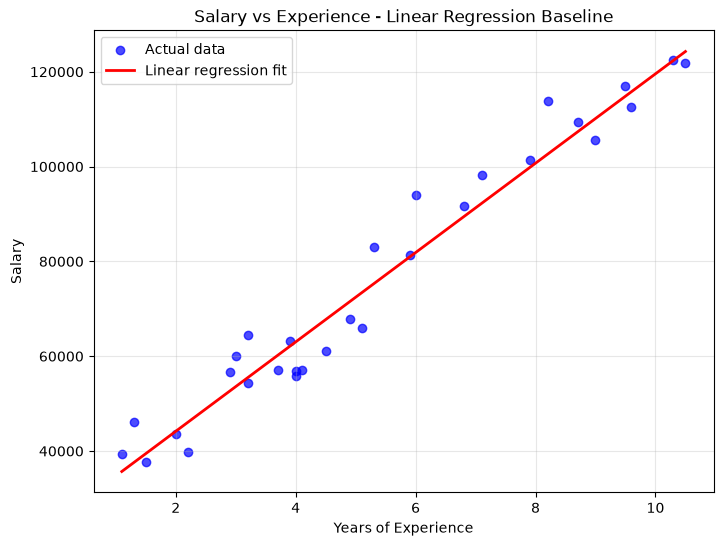

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual data')
plt.plot(
    np.sort(X['YearsExperience']),
    model.predict(np.sort(X[['YearsExperience']])),
    color='red',
    linewidth=2,
    label='Linear regression fit'
)
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience - Linear Regression Baseline')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Text(9.444444444444445, 0.5, 'count')

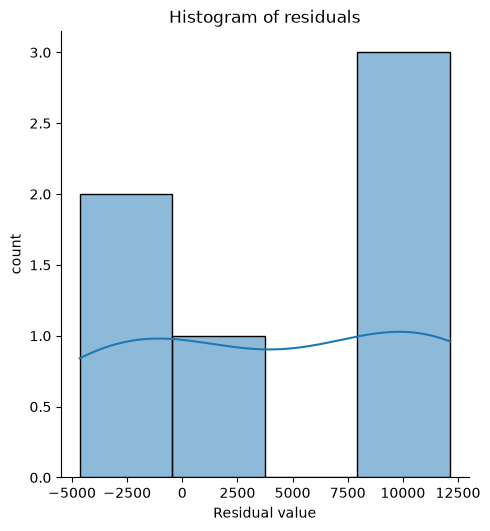

In [7]:
import seaborn as sns
 ## first compute vector of residuals. 
resids = np.subtract(y_test, y_pred)

## now make the residual plots
sns.displot(resids, kde = True)
plt.title('Histogram of residuals')
plt.xlabel('Residual value')
plt.ylabel('count')

DNN MAE: 6468.770333691081
DNN RMSE: 7921.247145267702
DNN R2: 0.8771600340123393


/Users/msayyadiharikan/Desktop/python/reddit/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


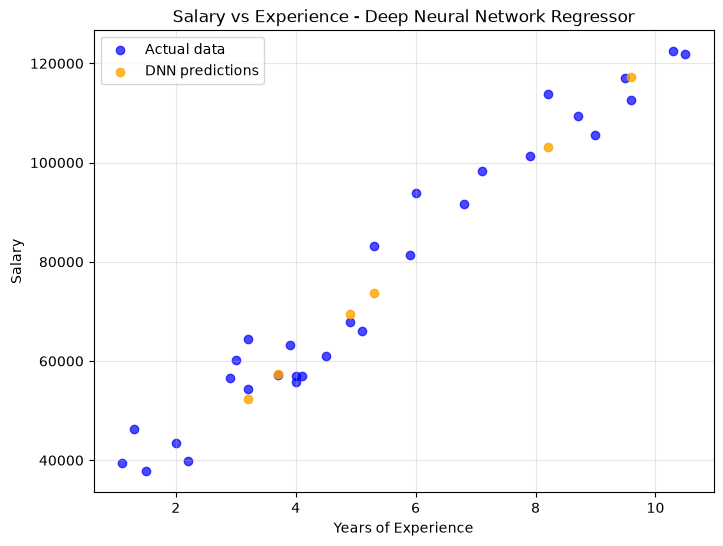

In [6]:
# Deep Neural Network Regressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

X = df[['YearsExperience']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

dnn = MLPRegressor(
    hidden_layer_sizes=(32, 32),
    activation='relu',
    solver='adam',
    random_state=42,
    max_iter=5000,
)

dnn.fit(X_train_scaled, y_train)
y_pred = dnn.predict(X_test_scaled)

print('DNN MAE:', mean_absolute_error(y_test, y_pred))
print('DNN RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('DNN R2:', r2_score(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', alpha=0.7, label='Actual data')
plt.scatter(X_test, y_pred, color='orange', alpha=0.8, label='DNN predictions')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience - Deep Neural Network Regressor')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
